# 06. Core Identification Assumptions

The previous lectures defined causal estimands such as ATE, ATT, ATC, and CATE. This lecture asks the next question:

> When can observed data identify those causal estimands?

Identification is not estimation. Identification is about whether the target causal quantity can, in principle, be learned from the observed data distribution under stated assumptions. Estimation is about how we compute a number from finite data.

For a binary treatment, the most common identification assumptions are:

1. **Consistency**: the observed outcome equals the potential outcome under the treatment actually received.
2. **Exchangeability**: treated and untreated units are comparable with respect to their potential outcomes, possibly after conditioning on covariates.
3. **Positivity**: every relevant type of unit has a nonzero chance of receiving each treatment level.
4. **SUTVA / no interference / well-defined treatments**: potential outcomes are not changed by other units' assignments, and treatment labels correspond to sufficiently specific treatment versions.

These assumptions are not ceremonial. They are the bridge between causal estimands and observed data.

## Learning Objectives

By the end of this lecture, you should be able to:

1. State the core identification assumptions in potential-outcomes notation.
2. Explain why randomization helps with exchangeability.
3. Diagnose confounding as a failure of exchangeability.
4. Explain why unobserved confounding cannot be solved by a more flexible model alone.
5. Diagnose positivity and overlap problems using propensity scores.
6. Recognize consistency problems from vague treatment definitions and treatment versions.
7. Recognize interference problems in marketplaces, networks, and shared-resource systems.
8. Separate identification assumptions from estimation choices.


## 1. Identification in One Equation

For the ATE, the target is:

$$
ATE = E[Y(1) - Y(0)]
$$

But observed data contain $Y$, not both $Y(1)$ and $Y(0)$. A common identification result says that, under consistency, conditional exchangeability, and positivity:

$$
E[Y(a)] = E_X\{E[Y \mid A=a, X]\}
$$

for $a \in \{0,1\}$. Therefore:

$$
ATE = E_X\{E[Y \mid A=1, X] - E[Y \mid A=0, X]\}
$$

This is the logic behind adjustment, matching, weighting, standardization, and many modern causal machine learning methods. The methods differ, but the assumptions do the causal work.

Rosenbaum and Rubin (1983) formalized the central role of the propensity score under strong ignorability. Westreich and Cole (2010) discuss positivity as a practical requirement. Cole and Frangakis (2009) focus on consistency, and Schwartz, Gatto, and Campbell (2012) discuss SUTVA as involving no interference and no hidden treatment versions.


In [1]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
from pathlib import Path
import sys


def _find_project_root(start=Path.cwd()):
    """
    Locate the portfolio project root so shared notebook utilities can be imported.
    
    Idea:
        The notebooks may be executed from different working directories, so this helper walks upward until it finds the repository structure used by the lecture series.
    
    Args:
        start: Directory where the upward search for the project root begins.
    
    Returns:
        pathlib.Path: Absolute path to the portfolio project root.
    """

    for candidate in [start, *start.parents]:
        if (candidate / "notebooks" / "_shared").exists():
            return candidate
    return start


PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from scipy.special import expit

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_colwidth", 115)
pd.set_option("display.precision", 3)

from notebooks._shared.display import smart_display

| assumption | notation | plain_language | business_diagnostic |
|---|---|---|---|
| Consistency | If A=a, then Y = Y(a) | The observed outcome matches the potential outcome for the treatment actually received. | Is the treatment label specific enough, and did units actually receive that version? |
| Exchangeability | (Y(1), Y(0)) independent of A given X | Within covariate strata, treatment assignment behaves as if random with respect to potential outcomes. | Do we understand why units were treated, and did we measure the drivers of both treatment and outcome? |
| Positivity | 0 < P(A=1 \| X=x) < 1 | Each relevant type of unit has some chance to receive treatment and control. | Do treated and control units overlap in the covariate profiles needed for adjustment? |
| SUTVA / no interference | Y_i(a) does not depend on A_j for j != i | One unit's potential outcome is not affected by another unit's treatment assignment. | Could spillovers, competition, budgets, queues, or network effects connect units? |


These assumptions are often written compactly, but each one is a real design question.

For example, suppose we estimate the effect of an LLM support assistant on resolution time. Consistency asks whether "assistant treatment" is a single well-defined workflow. Exchangeability asks whether tickets routed to the assistant are comparable to tickets not routed to it. Positivity asks whether every relevant ticket type appears in both workflows. SUTVA asks whether using the assistant for one ticket changes queue times for other tickets.

No estimator can answer these questions for us. Estimators can only operate after we decide what assumptions are plausible.

## 2. Consistency: Did the Unit Receive the Treatment We Defined?

Consistency says:

$$
Y_i = Y_i(A_i)
$$

If $A_i=1$, then $Y_i = Y_i(1)$. If $A_i=0$, then $Y_i = Y_i(0)$.

This sounds obvious, but in applied work it is often where ambiguity enters.

Examples of consistency problems:

- treatment is recorded as "coupon" but some customers receive 5%, some receive 10%, and some receive free shipping;
- treatment is recorded as "training" but some sellers attend live coaching while others only receive an email link;
- treatment is recorded as "LLM-assisted" but agents use the assistant in very different ways;
- assignment is recorded, but actual exposure or uptake differs.

The observed treatment must match the treatment strategy in the estimand.


| project | vague_treatment | better_treatment_definition |
|---|---|---|
| Retention coupon | Received an offer | Was sent a 10% discount email at campaign assignment time, with no other campaign discounts during 14-day follow-up |
| Seller enablement | Got training | Completed the two-hour onboarding webinar before the start of the 30-day outcome window |
| AI support workflow | Used AI | Ticket was routed to the LLM-assisted draft workflow before first human response |
| Recommendation ranking | New ranking model | Eligible session was served policy v2.3 for all recommendation slots during the session |


### Hidden Treatment Versions

Now consider a coded treatment called "retention outreach." It combines two versions:

- a self-serve coupon;
- a concierge retention call.

If these versions have different effects, then $Y(1)$ is not a single well-defined potential outcome unless the treatment strategy specifies the mix or version.


In [4]:
# Build the summary table used to connect the calculation back to the design question.
rng = np.random.default_rng(61)
n = 10_000
service_pain = rng.normal(0, 1, n)
price_sensitivity = np.clip(rng.beta(2.2, 2.8, n) + 0.12 * service_pain, 0, 1)
baseline_value = 55 - 8 * service_pain + rng.normal(0, 6, n)

coupon_effect = 3 + 13 * price_sensitivity - 2 * np.maximum(service_pain, 0)
concierge_effect = 2 + 12 * np.maximum(service_pain, 0) + 2 * price_sensitivity

current_mix_probability_coupon = 0.75
future_mix_probability_coupon = 0.25

current_outreach_effect = (
    current_mix_probability_coupon * coupon_effect
    + (1 - current_mix_probability_coupon) * concierge_effect
)
future_outreach_effect = (
    future_mix_probability_coupon * coupon_effect
    + (1 - future_mix_probability_coupon) * concierge_effect
)

pd.DataFrame(
    {
        "coded_treatment_strategy": [
            "Outreach = 75% coupon, 25% concierge call",
            "Outreach = 25% coupon, 75% concierge call",
            "Coupon version alone",
            "Concierge version alone",
        ],
        "average_effect": [
            current_outreach_effect.mean(),
            future_outreach_effect.mean(),
            coupon_effect.mean(),
            concierge_effect.mean(),
        ],
    }
)


,coded_treatment_strategy,average_effect
0,"Outreach = 75% coupon, 25% concierge call",7.925
1,"Outreach = 25% coupon, 75% concierge call",7.811
2,Coupon version alone,7.983
3,Concierge version alone,7.754


The same treatment label, "outreach," has different average effects depending on the mix of versions. If the historical data mostly contain coupons but the future rollout mostly uses concierge calls, the historical "outreach" effect may not transport to the future policy.

The fix is conceptual before it is statistical: define the treatment strategy precisely.

## 3. Exchangeability: Are Treated and Control Units Comparable?

Unconditional exchangeability is:

$$
(Y(1), Y(0)) \perp A
$$

Conditional exchangeability is:

$$
(Y(1), Y(0)) \perp A \mid X
$$

The conditional version says: after conditioning on measured covariates $X$, treatment assignment is unrelated to the potential outcomes.

In industry terms:

> Within comparable groups of customers, sellers, tickets, stores, or sessions, treatment assignment should not depend on what their treated or untreated outcomes would have been.

Randomization gives exchangeability by design. Observational studies require substantive argument and careful adjustment.


## 4. When Conditional Exchangeability Holds

We first simulate an observational setting where all confounders are observed.

A retention offer is more likely for high-risk, low-loyalty customers. Those same characteristics affect 60-day value. The true treatment effect is 5 dollars for everyone.

A naive comparison is biased. But adjustment for the observed confounders recovers the true effect approximately.


In [5]:
# Build the summary table used to connect the calculation back to the design question.
rng = np.random.default_rng(606)
n_customers = 25_000

risk_score = rng.normal(0, 1, n_customers)
loyalty_score = rng.normal(0, 1, n_customers)
monthly_margin = np.exp(3.2 + 0.25 * loyalty_score + rng.normal(0, 0.25, n_customers))

propensity = expit(-0.1 + 1.35 * risk_score - 0.65 * loyalty_score)
offer = rng.binomial(n=1, p=propensity)

true_tau = 5.0
value_no_offer = (
    50
    - 10 * risk_score
    + 8 * loyalty_score
    + 0.25 * monthly_margin
    + rng.normal(0, 8, n_customers)
)
value_offer = value_no_offer + true_tau
observed_value = np.where(offer == 1, value_offer, value_no_offer)

exchangeable_data = pd.DataFrame(
    {
        "net_value_60d": observed_value,
        "offer": offer,
        "risk_score": risk_score,
        "loyalty_score": loyalty_score,
        "monthly_margin": monthly_margin,
        "propensity": propensity,
        "_Y0_no_offer": value_no_offer,
        "_Y1_offer": value_offer,
        "_tau": value_offer - value_no_offer,
    }
)

exchangeable_data.head()


,net_value_60d,offer,risk_score,loyalty_score,monthly_margin,propensity,_Y0_no_offer,_Y1_offer,_tau
0,42.729,0,0.260,-0.650,13.656,0.662,42.729,47.729,5.0
1,43.857,1,1.621,-0.589,18.146,0.922,38.857,43.857,5.0
2,66.637,0,0.356,1.374,42.120,0.375,66.637,71.637,5.0
3,70.384,1,0.971,1.444,47.790,0.568,65.384,70.384,5.0
4,74.537,1,0.736,2.643,44.366,0.305,69.537,74.537,5.0


For When Conditional Exchangeability Holds, read the table as part of the estimand statement. The numbers only make sense after naming the treatment, comparison, outcome, population, and time horizon.

In [6]:
# Fit the statistical model and collect estimates used in the following interpretation.
true_ate = exchangeable_data["_tau"].mean()
naive_difference = (
    exchangeable_data.loc[exchangeable_data["offer"] == 1, "net_value_60d"].mean()
    - exchangeable_data.loc[exchangeable_data["offer"] == 0, "net_value_60d"].mean()
)

naive_model = smf.ols("net_value_60d ~ offer", data=exchangeable_data).fit()
adjusted_model = smf.ols(
    "net_value_60d ~ offer + risk_score + loyalty_score + monthly_margin",
    data=exchangeable_data,
).fit()

pd.DataFrame(
    {
        "quantity": [
            "True ATE",
            "Naive observed difference",
            "OLS without confounder adjustment",
            "OLS adjusted for observed confounders",
        ],
        "value": [
            true_ate,
            naive_difference,
            naive_model.params["offer"],
            adjusted_model.params["offer"],
        ],
    }
)


,quantity,value
0,True ATE,5.000
1,Naive observed difference,-8.965
2,OLS without confounder adjustment,-8.965
3,OLS adjusted for observed confounders,4.848


In When Conditional Exchangeability Holds, read the model output after checking the graph. A clean coefficient can still answer the wrong counterfactual question.

In [7]:
# Assemble the When Conditional Exchangeability Holds summary table used for interpretation.
balance_table = (
    exchangeable_data.groupby("offer")
    .agg(
        n=("net_value_60d", "size"),
        observed_value=("net_value_60d", "mean"),
        risk_score=("risk_score", "mean"),
        loyalty_score=("loyalty_score", "mean"),
        baseline_Y0=("_Y0_no_offer", "mean"),
    )
    .rename(index={0: "No offer", 1: "Offer"})
)

smart_display(balance_table)


,n,observed_value,risk_score,loyalty_score,baseline_Y0
offer,,,,,
No offer,12927,63.214,-0.460,0.216,63.214
Offer,12073,54.249,0.497,-0.237,49.249


The naive difference is negative even though the true effect is positive. Treated customers have higher risk, lower loyalty, and lower baseline potential outcomes.

After adjusting for the confounders used to assign treatment and generate the outcome, the estimated offer effect moves close to the true ATE.

This example is friendly because conditional exchangeability actually holds: after conditioning on the observed variables, treatment assignment is as good as random with respect to potential outcomes.

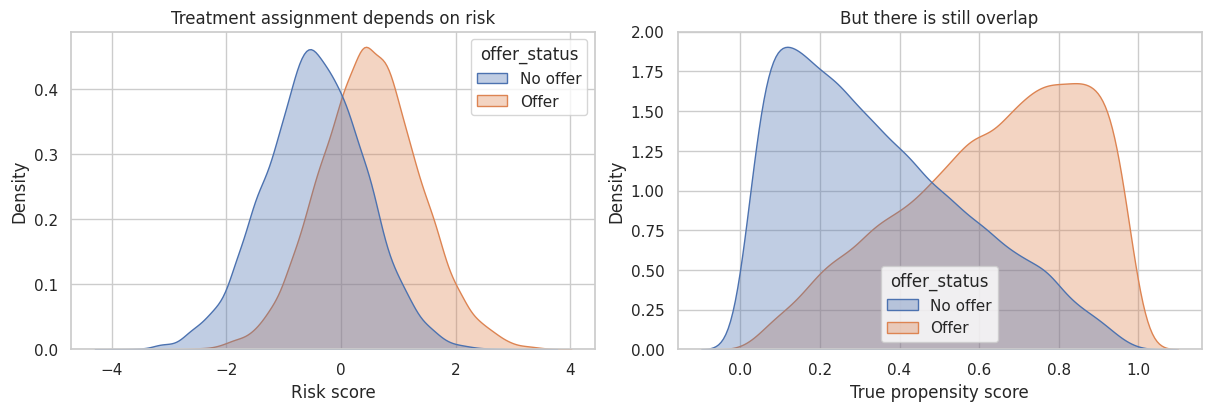

In [8]:
# Prepare the diagnostic display and label the design features that matter for interpretation.
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
plot_data = exchangeable_data.assign(offer_status=exchangeable_data["offer"].map({0: "No offer", 1: "Offer"}))

sns.kdeplot(
    data=plot_data,
    x="risk_score",
    hue="offer_status",
    common_norm=False,
    fill=True,
    alpha=0.35,
    ax=axes[0],
)
axes[0].set_title("Treatment assignment depends on risk")
axes[0].set_xlabel("Risk score")

sns.kdeplot(
    data=plot_data,
    x="propensity",
    hue="offer_status",
    common_norm=False,
    fill=True,
    alpha=0.35,
    ax=axes[1],
)
axes[1].set_title("But there is still overlap")
axes[1].set_xlabel("True propensity score")

plt.show()


The treated and untreated groups differ, but they overlap. We can find high-risk customers who did not receive offers and lower-risk customers who did. That overlap matters for adjustment.

The next example keeps the same intuition but adds a latent confounder that we do not measure.

## 5. When Exchangeability Fails: Unobserved Confounding

Now suppose there is an unobserved customer trait, such as account-level negotiation pressure or hidden retention intent, that affects both treatment assignment and the outcome.

We adjust for observed risk and loyalty, but not the unobserved trait. Conditional exchangeability fails:

$$
(Y(1), Y(0)) \not\perp A \mid X_{observed}
$$

A flexible model would not solve this by itself. The missing variable is a design problem, not merely a modeling problem.


In [9]:
# Fit the statistical model and collect estimates used in the following interpretation.
rng = np.random.default_rng(607)
n_customers = 25_000

hidden_urgency = rng.normal(0, 1, n_customers)
risk_score = rng.normal(0, 1, n_customers)
loyalty_score = rng.normal(0, 1, n_customers)

propensity_hidden = expit(
    -0.1
    + 1.0 * risk_score
    - 0.5 * loyalty_score
    + 1.2 * hidden_urgency
)
offer_hidden = rng.binomial(n=1, p=propensity_hidden)

value_no_offer_hidden = (
    50
    - 8 * risk_score
    + 7 * loyalty_score
    + 12 * hidden_urgency
    + rng.normal(0, 8, n_customers)
)
value_offer_hidden = value_no_offer_hidden + 5
observed_value_hidden = np.where(offer_hidden == 1, value_offer_hidden, value_no_offer_hidden)

hidden_data = pd.DataFrame(
    {
        "net_value_60d": observed_value_hidden,
        "offer": offer_hidden,
        "risk_score": risk_score,
        "loyalty_score": loyalty_score,
        "hidden_urgency": hidden_urgency,
        "_tau": value_offer_hidden - value_no_offer_hidden,
    }
)

models_hidden = pd.DataFrame(
    {
        "quantity": [
            "True ATE",
            "Naive observed difference",
            "Adjusted for observed covariates only",
            "Adjusted for observed covariates plus hidden confounder",
        ],
        "value": [
            hidden_data["_tau"].mean(),
            hidden_data.loc[hidden_data["offer"] == 1, "net_value_60d"].mean()
            - hidden_data.loc[hidden_data["offer"] == 0, "net_value_60d"].mean(),
            smf.ols("net_value_60d ~ offer + risk_score + loyalty_score", data=hidden_data).fit().params["offer"],
            smf.ols("net_value_60d ~ offer + risk_score + loyalty_score + hidden_urgency", data=hidden_data).fit().params["offer"],
        ],
    }
)

smart_display(models_hidden)


,quantity,value
0,True ATE,5.000
1,Naive observed difference,7.104
2,Adjusted for observed covariates only,16.345
3,Adjusted for observed covariates plus hidden confounder,4.871


Adjustment using only observed covariates does not recover the true effect. Once we include the hidden confounder, the estimate moves close to the truth.

In real data, we do not get to include a column called `hidden_urgency`. This is why causal inference requires design knowledge: how treatment was assigned, what common causes were measured, what was missing, and how sensitive the conclusion is to unmeasured confounding.

## 6. Positivity: Do We Have Comparable Units?

Positivity requires that every covariate profile needed for adjustment has a chance to receive each treatment level:

$$
0 < P(A=1 \mid X=x) < 1
$$

If enterprise customers always receive a concierge intervention and small customers never receive it, the data cannot teach us the effect of concierge service for small customers without extrapolation.

There are two common versions:

- **Structural positivity violation**: treatment is impossible for some group by policy, regulation, or product constraints.
- **Practical positivity problem**: treatment is technically possible but extremely rare for some group, creating unstable estimates.


In [10]:
# Build the summary table used to connect the calculation back to the design question.
rng = np.random.default_rng(608)
n = 25_000

segment = rng.choice(["low", "mid", "high"], size=n, p=[0.30, 0.40, 0.30])
usage_score = rng.normal(0, 1, n)

propensity_overlap = np.where(
    segment == "low",
    expit(-4 + 0.5 * usage_score),
    np.where(segment == "mid", expit(0 + 0.5 * usage_score), expit(4 + 0.5 * usage_score)),
)
treatment = rng.binomial(n=1, p=propensity_overlap)

segment_effect = 4 + 2 * (segment == "high") - 1 * (segment == "low")
y0 = 40 + 6 * usage_score + 8 * (segment == "high") - 5 * (segment == "low") + rng.normal(0, 5, n)
y1 = y0 + segment_effect
y = np.where(treatment == 1, y1, y0)

overlap_data = pd.DataFrame(
    {
        "outcome": y,
        "treatment": treatment,
        "segment": segment,
        "usage_score": usage_score,
        "propensity": propensity_overlap,
        "_tau": segment_effect,
    }
)

overlap_data.groupby("segment").agg(
    treatment_rate=("treatment", "mean"),
    n=("treatment", "size"),
    true_effect=("_tau", "mean"),
)


,treatment_rate,n,true_effect
segment,,,
high,0.981,7527,6.0
low,0.019,7574,3.0
mid,0.501,9899,4.0


In Positivity: Do We Have Comparable Units, the table keeps the counterfactual gap in view. This is the missing-outcome problem in miniature: one observed result, two potential worlds.

In [11]:
# Fit the statistical model and collect estimates used in the following interpretation.
weights = (
    overlap_data["treatment"] / overlap_data["propensity"]
    + (1 - overlap_data["treatment"]) / (1 - overlap_data["propensity"])
)

treated_weights = overlap_data["treatment"] / overlap_data["propensity"]
control_weights = (1 - overlap_data["treatment"]) / (1 - overlap_data["propensity"])

ipw_estimate = (
    (treated_weights * overlap_data["outcome"]).sum() / treated_weights.sum()
    - (control_weights * overlap_data["outcome"]).sum() / control_weights.sum()
)

trim_mask = (overlap_data["propensity"] > 0.05) & (overlap_data["propensity"] < 0.95)
trim_data = overlap_data.loc[trim_mask].copy()
trim_treated_weights = trim_data["treatment"] / trim_data["propensity"]
trim_control_weights = (1 - trim_data["treatment"]) / (1 - trim_data["propensity"])
trim_ipw_estimate = (
    (trim_treated_weights * trim_data["outcome"]).sum() / trim_treated_weights.sum()
    - (trim_control_weights * trim_data["outcome"]).sum() / trim_control_weights.sum()
)

pd.DataFrame(
    {
        "quantity": [
            "True ATE in full population",
            "Naive observed difference",
            "Regression adjusted for segment and usage",
            "IPW using true propensity scores",
            "Share retained after overlap trimming",
            "True ATE in trimmed overlap population",
            "Trimmed IPW estimate",
        ],
        "value": [
            overlap_data["_tau"].mean(),
            overlap_data.loc[overlap_data["treatment"] == 1, "outcome"].mean()
            - overlap_data.loc[overlap_data["treatment"] == 0, "outcome"].mean(),
            smf.ols("outcome ~ treatment + usage_score + C(segment)", data=overlap_data).fit().params["treatment"],
            ipw_estimate,
            trim_mask.mean(),
            trim_data["_tau"].mean(),
            trim_ipw_estimate,
        ],
    }
)


,quantity,value
0,True ATE in full population,4.299
1,Naive observed difference,13.988
2,Regression adjusted for segment and usage,4.111
3,IPW using true propensity scores,4.977
4,Share retained after overlap trimming,0.407
5,True ATE in trimmed overlap population,4.012
6,Trimmed IPW estimate,4.196


In Positivity: Do We Have Comparable Units, read the model output against the counterfactual target. We observe one realized outcome per unit, while the estimand compares two possible worlds.

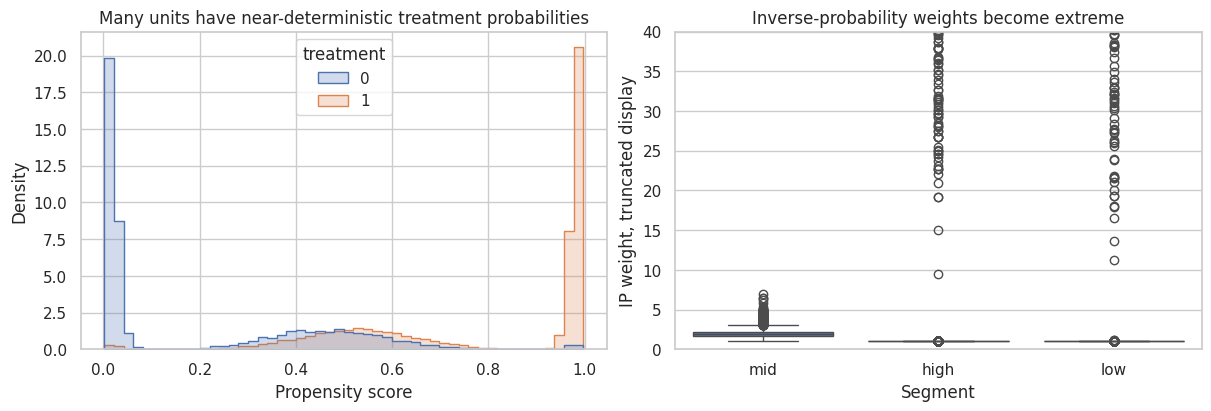

In [12]:
# Prepare the diagnostic display and label the design features that matter for interpretation.
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

sns.histplot(
    data=overlap_data,
    x="propensity",
    hue="treatment",
    bins=50,
    element="step",
    stat="density",
    common_norm=False,
    ax=axes[0],
)
axes[0].set_title("Many units have near-deterministic treatment probabilities")
axes[0].set_xlabel("Propensity score")

sns.boxplot(
    data=pd.DataFrame({"weight": weights, "segment": overlap_data["segment"]}),
    x="segment",
    y="weight",
    ax=axes[1],
)
axes[1].set_ylim(0, 40)
axes[1].set_title("Inverse-probability weights become extreme")
axes[1].set_xlabel("Segment")
axes[1].set_ylabel("IP weight, truncated display")

plt.show()


The low segment almost never receives treatment, while the high segment almost always receives it. That creates weak overlap.

With weak overlap, adjustment relies heavily on extrapolation. Weighting methods can become unstable because the few units who received the unlikely treatment get enormous weights.

Trimming changes the target population. The trimmed estimate targets an overlap population, not the full original population. That can be the right decision, but it must be reported clearly.

## 7. SUTVA and Interference: What if Units Affect Each Other?

No interference says unit $i$'s potential outcome depends only on unit $i$'s treatment:

$$
Y_i = Y_i(A_i)
$$

With interference, the potential outcome may depend on other units' assignments:

$$
Y_i = Y_i(A_i, A_{-i})
$$

This is common in industry:

- marketplace sellers compete for the same buyers;
- ads compete for a shared budget;
- support tickets compete for agent capacity;
- social-product users influence one another;
- recommendations change what other items can be seen.

Individual-level randomization may estimate a direct effect while missing spillovers or equilibrium effects.


In [13]:
# Build the summary table used to connect the calculation back to the design question.
rng = np.random.default_rng(609)
n_markets = 200
units_per_market = 100
n = n_markets * units_per_market

market_id = np.repeat(np.arange(n_markets), units_per_market)
market_effect = rng.normal(0, 4, n_markets)[market_id]
base = 50 + market_effect + rng.normal(0, 5, n)

direct_effect = 5.0
negative_spillover_per_market_share_treated = -4.0

# Individual randomization at 50% saturation within markets.
individual_treatment = rng.binomial(n=1, p=0.5, size=n)
market_treatment_share = pd.Series(individual_treatment).groupby(market_id).transform("mean").to_numpy()
individual_randomized_outcome = (
    base
    + direct_effect * individual_treatment
    + negative_spillover_per_market_share_treated * market_treatment_share
)

individual_diff = (
    individual_randomized_outcome[individual_treatment == 1].mean()
    - individual_randomized_outcome[individual_treatment == 0].mean()
)

# Policy contrasts under interference.
outcome_if_no_markets_treated = base + direct_effect * 0 + negative_spillover_per_market_share_treated * 0
outcome_if_all_markets_treated = base + direct_effect * 1 + negative_spillover_per_market_share_treated * 1
total_policy_effect_all_vs_none = outcome_if_all_markets_treated.mean() - outcome_if_no_markets_treated.mean()

pd.DataFrame(
    {
        "quantity": [
            "Direct effect parameter in the data-generating process",
            "Individual randomized treated-minus-control difference",
            "Total policy effect of treating everyone versus no one",
        ],
        "value": [direct_effect, individual_diff, total_policy_effect_all_vs_none],
    }
)


,quantity,value
0,Direct effect parameter in the data-generating process,5.000
1,Individual randomized treated-minus-control difference,4.854
2,Total policy effect of treating everyone versus no one,1.000


The individual randomized comparison is close to the direct effect. But the total policy effect of treating everyone is much smaller because the intervention creates negative spillovers through market saturation.

Neither number is automatically wrong. They answer different questions:

- direct effect holding market saturation roughly fixed;
- total policy effect of changing treatment saturation for the whole market.

When interference is plausible, the estimand must include the exposure pattern or policy saturation level. Cluster randomization, marketplace-level experiments, switchback designs, or explicit spillover models may be needed.

## 8. Practical Diagnostic Checklist

Before estimating an observational causal effect, ask:

1. **Consistency**: What exactly is treatment? Was treatment received as defined? Are there multiple versions?
2. **Exchangeability**: Why did some units receive treatment? Have we measured the common causes of treatment and outcome?
3. **Positivity**: Within the covariates needed for adjustment, do we observe both treated and untreated units?
4. **SUTVA**: Can one unit's treatment affect another unit's outcome? Are there shared budgets, queues, networks, or equilibrium effects?
5. **Timing**: Are covariates measured before treatment? Are we accidentally adjusting for post-treatment variables?
6. **Measurement**: Are treatment, outcome, and confounders measured accurately enough for the estimand?
7. **Target population**: If we trim or restrict to overlap, have we changed the estimand?
8. **Sensitivity**: What violations are most plausible, and how would they change the conclusion?


| assumption | red_flag | possible_response |
|---|---|---|
| Consistency | Treatment label mixes many versions or actual exposure differs from assignment. | Redefine treatment strategy; analyze assignment and uptake separately; report version-specific effects. |
| Exchangeability | Treatment was targeted using judgment, risk scores, eligibility rules, or hidden information. | Measure assignment drivers; adjust; use design variation; run experiment; conduct sensitivity analysis. |
| Positivity | Some segments are nearly all treated or nearly all untreated. | Restrict to overlap population; avoid extrapolation; redesign data collection or experiment. |
| SUTVA | Treatment changes capacity, prices, rankings, budgets, or peer behavior. | Use cluster/switchback design; define spillover estimands; model exposure mappings. |
| Timing | Controls include variables measured after treatment assignment. | Use pre-treatment covariates only for baseline adjustment; handle mediators separately. |


## 9. Key Takeaways

1. Identification assumptions connect potential-outcome estimands to observed data.
2. Consistency requires that observed outcomes correspond to the treatment strategy actually received.
3. Exchangeability requires treated and untreated units to be comparable with respect to potential outcomes, possibly after conditioning on covariates.
4. Positivity requires overlap: every relevant covariate profile must have a chance to receive each treatment level.
5. SUTVA requires well-defined treatments and no interference between units.
6. Randomization helps with exchangeability while consistency, interference, measurement, and external-validity problems still need separate checks.
7. Weak overlap changes what can be learned; trimming can be useful but changes the target population.
8. Unobserved confounding is not solved by using a more flexible predictive model.
9. Identification is a design and assumptions problem before it is an estimation problem.

## Preview of the Next Lecture

The next lecture introduces causal DAGs and graphical assumptions. DAGs give us a visual language for confounding, adjustment, mediators, colliders, and selection bias.


## References

- Cole, S. R., & Frangakis, C. E. (2009). The consistency statement in causal inference. *Epidemiology, 20*(1), 3-5. https://doi.org/10.1097/EDE.0b013e31818ef366. Access: publisher / DOI page.
- Rosenbaum, P. R., & Rubin, D. B. (1983). The central role of the propensity score in observational studies for causal effects. *Biometrika, 70*(1), 41-55. https://doi.org/10.1093/biomet/70.1.41. Access: open / DOI page.
- Saarela, O., Stephens, D. A., & Moodie, E. E. M. (2020). The role of exchangeability in causal inference. *arXiv*. https://doi.org/10.48550/arxiv.2006.01799. Access: open / DOI page.
- Schwartz, S., Gatto, N. M., & Campbell, U. B. (2012). Extending the sufficient component cause model to describe the Stable Unit Treatment Value Assumption (SUTVA). *Epidemiologic Perspectives & Innovations, 9*, 3. https://doi.org/10.1186/1742-5573-9-3. Access: open / DOI page.
- Westreich, D., & Cole, S. R. (2010). Invited commentary: Positivity in practice. *American Journal of Epidemiology, 171*(6), 674-677. https://doi.org/10.1093/aje/kwp436. Access: open / DOI page.
